Iris QNN | 5 MZI layers | Perceval 1.1.0 + Merlin
Modes: 8
Input features: 4
Trainable quantum parameters: 70
Trainable prefixes: ['w1_', 'inter1_', 'w2_', 'inter2_', 'w3_', 'inter3_', 'w4_', 'inter4_', 'w5_', 'inter5_']

[Local mode] Differentiable Merlin training
Epoch 01/100 | train_loss=0.3429 | train_acc=0.971 | test_loss=0.2031 | test_acc=0.967 | time=1.418s
Epoch 02/100 | train_loss=0.1239 | train_acc=1.000 | test_loss=0.0867 | test_acc=0.967 | time=1.413s
Epoch 03/100 | train_loss=0.0461 | train_acc=1.000 | test_loss=0.0356 | test_acc=1.000 | time=1.450s
Epoch 04/100 | train_loss=0.0185 | train_acc=1.000 | test_loss=0.0193 | test_acc=1.000 | time=1.438s
Epoch 05/100 | train_loss=0.0108 | train_acc=1.000 | test_loss=0.0126 | test_acc=1.000 | time=1.485s
Epoch 06/100 | train_loss=0.0070 | train_acc=1.000 | test_loss=0.0099 | test_acc=1.000 | time=1.386s
Epoch 07/100 | train_loss=0.0050 | train_acc=1.000 | test_loss=0.0080 | test_acc=1.000 | time=1.365s
Epoch 08/100 | train_loss=0

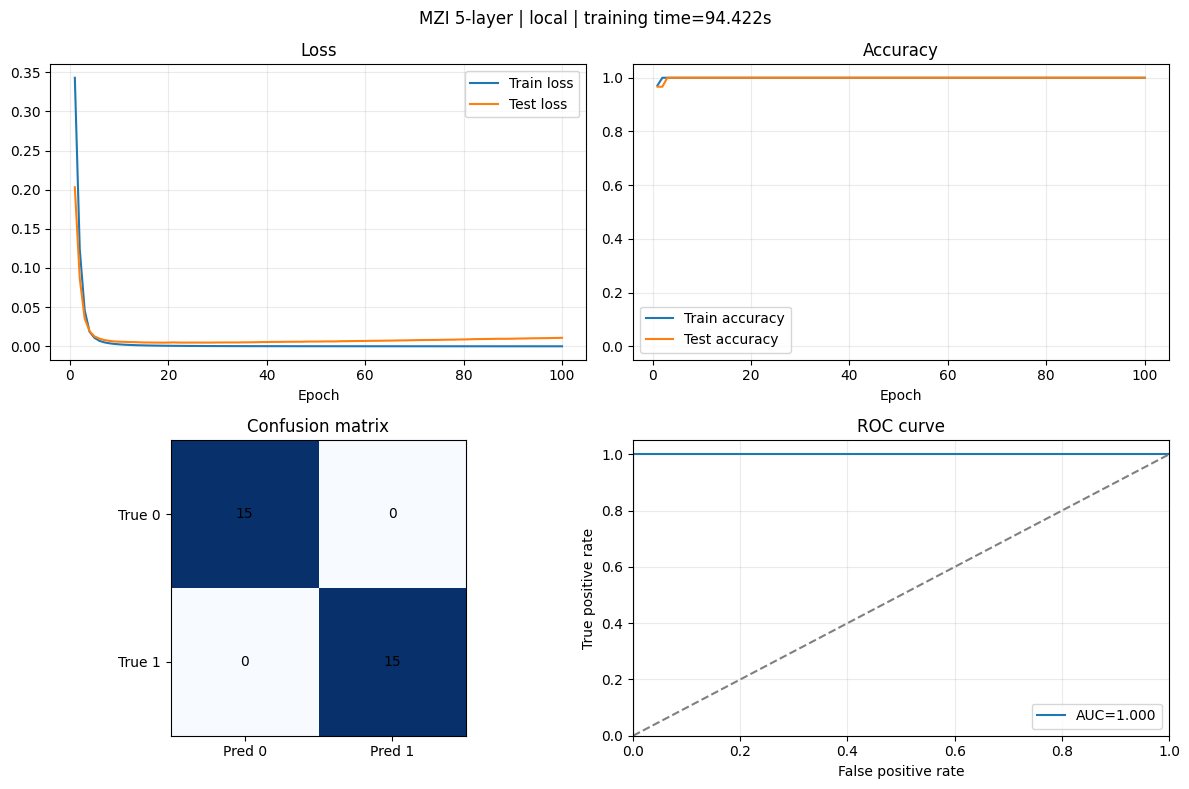

In [ ]:
"""Iris QNN with local Merlin training and BSCount-driven Belenos training."""

import json
import math
import os
import time

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

import perceval as pcvl
from perceval.algorithm import Sampler
from perceval.components import BS, PS

import merlin as ML

from sklearn.datasets import load_iris as sklearn_load_iris
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset


# ============================================================
# Configuration
# ============================================================

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

N_QUBITS = 4
N_MODES = 2 * N_QUBITS
N_FEATURES = 4
N_LAYERS = 5

IRIS_CLASS_0 = 0
IRIS_CLASS_1 = 1
TRAIN_SIZE = 70
TEST_SIZE = 30

LOCAL_EPOCHS = 100
LOCAL_BATCH_SIZE = 4
LOCAL_LR = 0.01

AUTO_PLOT = True
AUTO_SAVE_HISTORY = True
HISTORY_DIRECTORY = r"C:\Quantum"

# False: differentiable local Merlin training.
# True: hardware-in-the-loop SPSA training from qpu:belenos BSCount.
RUN_BELENOS = False
QPU_NAME = os.getenv("QUANDELA_PLATFORM", "qpu:belenos")
QPU_TOKEN = os.getenv("QUANDELA_CLOUD_TOKEN") or None
QPU_SHOTS = 300
QPU_SPSA_STEPS = 2
QPU_BATCH_SIZE = 2
QPU_TEST_SAMPLES = 5
QPU_CLASSICAL_LR = 0.02

SPSA_A0 = 0.12
SPSA_C0 = 0.18
SPSA_ALPHA = 0.602
SPSA_GAMMA = 0.101
SPSA_STABILITY = 3.0


# ============================================================
# Dataset
# ============================================================

def get_iris_binary_dataset():
    iris = sklearn_load_iris()
    x_all = iris.data.astype(np.float32)
    y_all = iris.target.astype(np.int64)

    mask = (y_all == IRIS_CLASS_0) | (y_all == IRIS_CLASS_1)
    x_all = x_all[mask]
    y_all = (y_all[mask] == IRIS_CLASS_1).astype(np.float32)

    x_train, x_test, y_train, y_test = train_test_split(
        x_all,
        y_all,
        train_size=TRAIN_SIZE,
        test_size=TEST_SIZE,
        random_state=SEED,
        stratify=y_all,
    )

    scaler = MinMaxScaler(feature_range=(0.0, 2.0 * math.pi))
    x_train = scaler.fit_transform(x_train)
    x_test = scaler.transform(x_test)

    return (
        torch.tensor(x_train, dtype=torch.float32),
        torch.tensor(x_test, dtype=torch.float32),
        torch.tensor(y_train, dtype=torch.float32),
        torch.tensor(y_test, dtype=torch.float32),
    )


# ============================================================
# Shared photonic circuit
# ============================================================

def build_photonic_qnn():
    slos_processor = pcvl.Processor("SLOS", N_MODES)
    x_params = [pcvl.P(f"x{i}") for i in range(N_FEATURES)]
    trainable_params = []
    trainable_prefixes = []

    # MZI-like encoding makes input phases observable in output statistics.
    for qubit in range(N_QUBITS):
        slos_processor.add(2 * qubit, BS.Ry())
        slos_processor.add(2 * qubit + 1, PS(phi=x_params[qubit]))
        slos_processor.add(2 * qubit, BS.Ry())

    for layer in range(1, N_LAYERS + 1):
        weight_prefix = f"w{layer}_"
        inter_prefix = f"inter{layer}_"
        trainable_prefixes.extend([weight_prefix, inter_prefix])

        weights = [pcvl.P(f"{weight_prefix}{mode}") for mode in range(N_MODES)]
        inter_params = [pcvl.P(f"{inter_prefix}{mode}") for mode in range(1, 7)]
        trainable_params.extend(weights)
        trainable_params.extend(inter_params)

        weight_index = 0
        for qubit in range(N_QUBITS):
            slos_processor.add(2 * qubit, PS(phi=weights[weight_index]))
            weight_index += 1
            slos_processor.add(2 * qubit + 1, PS(phi=weights[weight_index]))
            weight_index += 1
            slos_processor.add(2 * qubit, BS.Ry())

        for start in (1, 3, 5):
            slos_processor.add((start, start + 1), BS.Ry())

        for mode in range(1, 7):
            slos_processor.add(mode, PS(phi=inter_params[mode - 1]))

        for qubit in range(N_QUBITS):
            slos_processor.add(2 * qubit, BS.Ry())

    circuit = slos_processor.linear_circuit()
    return circuit, slos_processor, x_params, trainable_params, trainable_prefixes


class IrisPhotonicQNN(nn.Module):
    def __init__(self, circuit, trainable_prefixes):
        super().__init__()

        measurement = ML.MeasurementStrategy.mode_expectations(
            computation_space=ML.ComputationSpace.UNBUNCHED
        )

        self.q_layer = ML.QuantumLayer(
            input_size=N_FEATURES,
            circuit=circuit,
            input_state=pcvl.BasicState([1, 0] * N_QUBITS),
            n_photons=N_QUBITS,
            input_parameters=["x"],
            trainable_parameters=trainable_prefixes,
            measurement_strategy=measurement,
            dtype=torch.float32,
        )

        self.fc = nn.Sequential(
            nn.LayerNorm(N_MODES),
            nn.Linear(N_MODES, 1),
        )

    def forward(self, x):
        expectations = self.q_layer(x)
        if expectations.dim() == 1:
            expectations = expectations.unsqueeze(0)
        return self.fc(expectations).squeeze(-1)


# ============================================================
# Metrics and local differentiable training
# ============================================================

def metrics_from_logits(logits, targets, criterion):
    loss = criterion(logits, targets)
    probabilities = torch.sigmoid(logits)
    predictions = (probabilities >= 0.5).float()
    accuracy = (predictions == targets).float().mean()
    return loss, accuracy, probabilities, predictions


def classification_metrics_from_probabilities(targets, probabilities):
    y_true = targets.detach().cpu().numpy().astype(np.int64)
    y_probability = probabilities.detach().cpu().numpy()
    y_prediction = (y_probability >= 0.5).astype(np.int64)

    matrix = confusion_matrix(y_true, y_prediction, labels=[0, 1])
    precision = precision_score(y_true, y_prediction, zero_division=0)
    recall = recall_score(y_true, y_prediction, zero_division=0)
    roc_auc = (
        roc_auc_score(y_true, y_probability)
        if np.unique(y_true).size == 2
        else float("nan")
    )

    return {
        "confusion_matrix": matrix,
        "precision": float(precision),
        "recall": float(recall),
        "roc_auc": float(roc_auc),
    }


def print_classification_metrics(label, targets, probabilities):
    metrics = classification_metrics_from_probabilities(targets, probabilities)
    matrix = metrics["confusion_matrix"]
    print(f"{label} confusion matrix [[TN, FP], [FN, TP]]: {matrix.tolist()}")
    print(f"{label} precision: {metrics['precision']:.4f}")
    print(f"{label} recall/sensitivity: {metrics['recall']:.4f}")
    print(f"{label} ROC-AUC: {metrics['roc_auc']:.4f}")
    return metrics


def evaluate_local(model, x, y, criterion):
    model.eval()
    with torch.no_grad():
        return metrics_from_logits(model(x), y, criterion)


def train_local(model, x_train, x_test, y_train, y_test):
    loader = DataLoader(
        TensorDataset(x_train, y_train),
        batch_size=LOCAL_BATCH_SIZE,
        shuffle=True,
    )
    optimizer = optim.Adam(model.parameters(), lr=LOCAL_LR)
    criterion = nn.BCEWithLogitsLoss()
    total_start = time.time()

    history = {
        "mode": "local",
        "layers": N_LAYERS,
        "dataset": {
            "train_samples": int(len(x_train)),
            "test_samples": int(len(x_test)),
            "evaluated_test_samples": int(len(x_test)),
        },
        "epoch": [],
        "train_loss": [],
        "train_accuracy": [],
        "test_loss": [],
        "test_accuracy": [],
        "epoch_time_s": [],
    }
    quantum_before = {
        name: parameter.detach().clone()
        for name, parameter in model.q_layer.named_parameters()
    }

    training_start = time.time()
    for epoch in range(1, LOCAL_EPOCHS + 1):
        epoch_start = time.time()
        model.train()
        total_loss = 0.0

        for xb, yb in loader:
            optimizer.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * len(xb)

        train_loss = total_loss / len(x_train)
        _, train_acc, _, _ = evaluate_local(model, x_train, y_train, criterion)
        test_loss, test_acc, _, _ = evaluate_local(model, x_test, y_test, criterion)
        epoch_time = time.time() - epoch_start

        history["epoch"].append(epoch)
        history["train_loss"].append(float(train_loss))
        history["train_accuracy"].append(float(train_acc.item()))
        history["test_loss"].append(float(test_loss.item()))
        history["test_accuracy"].append(float(test_acc.item()))
        history["epoch_time_s"].append(float(epoch_time))

        print(
            f"Epoch {epoch:02d}/{LOCAL_EPOCHS} | "
            f"train_loss={train_loss:.4f} | train_acc={train_acc.item():.3f} | "
            f"test_loss={test_loss.item():.4f} | test_acc={test_acc.item():.3f} | "
            f"time={epoch_time:.3f}s"
        )

    training_time = time.time() - training_start
    evaluation_start = time.time()
    test_loss, test_acc, probabilities, predictions = evaluate_local(
        model, x_test, y_test, criterion
    )
    evaluation_time = time.time() - evaluation_start
    total_wall_time = time.time() - total_start

    max_delta = max(
        (parameter.detach() - quantum_before[name]).abs().max().item()
        for name, parameter in model.q_layer.named_parameters()
    )
    classification = print_classification_metrics("Local test", y_test, probabilities)

    history["timing"] = {
        "training_time_s": float(training_time),
        "evaluation_time_s": float(evaluation_time),
        "total_wall_time_s": float(total_wall_time),
    }
    history["final_test"] = {
        "loss": float(test_loss.item()),
        "accuracy": float(test_acc.item()),
        "precision": classification["precision"],
        "recall_sensitivity": classification["recall"],
        "roc_auc": classification["roc_auc"],
        "confusion_matrix": classification["confusion_matrix"].tolist(),
        "probabilities": probabilities.tolist(),
        "predictions": predictions.tolist(),
        "labels": y_test.tolist(),
    }
    history["quantum_parameter_max_delta"] = float(max_delta)

    print(f"Local training time: {training_time:.3f}s")
    print(f"Local final evaluation time: {evaluation_time:.3f}s")
    print(f"Local total wall time: {total_wall_time:.3f}s")
    print("Quantum parameters updated:", max_delta > 0)
    print("Max |delta quantum parameters|:", max_delta)
    print(f"Final local loss={test_loss.item():.4f} | accuracy={test_acc.item():.3f}")
    print("Probabilities:", probabilities.tolist())
    print("Predictions  :", predictions.tolist())
    print("Labels       :", y_test.tolist())
    return history


# ============================================================
# Merlin parameter storage <-> Perceval parameter names
# ============================================================

def parameter_layout():
    layout = []
    for layer in range(1, N_LAYERS + 1):
        layout.append((f"w{layer}_", N_MODES, 0))
        layout.append((f"inter{layer}_", 6, 1))
    return layout


def flatten_quantum_parameters(model):
    chunks = []
    for prefix, _, _ in parameter_layout():
        chunks.append(getattr(model.q_layer, prefix).detach().flatten())
    return torch.cat(chunks).clone()


def assign_quantum_parameters(model, theta):
    offset = 0
    with torch.no_grad():
        for prefix, size, _ in parameter_layout():
            parameter = getattr(model.q_layer, prefix)
            parameter.copy_(theta[offset : offset + size].view_as(parameter))
            offset += size


def wrap_phases(theta):
    return torch.remainder(theta + math.pi, 2.0 * math.pi) - math.pi


def theta_to_perceval_parameters(theta):
    values = {}
    offset = 0

    for prefix, size, first_index in parameter_layout():
        for local_index in range(size):
            values[f"{prefix}{local_index + first_index}"] = float(
                theta[offset + local_index]
            )
        offset += size

    return values


def input_to_perceval_parameters(x):
    return {f"x{index}": float(x[index]) for index in range(N_FEATURES)}


# ============================================================
# Belenos BSCount execution and expectation values
# ============================================================

def bscount_to_mode_expectations(counts):
    """Convert BSCount to Merlin UNBUNCHED mode expectation values."""
    total_count = float(sum(counts.values()))
    if total_count <= 0:
        raise RuntimeError("The QPU returned an empty BSCount result.")

    expectations = torch.zeros(N_MODES, dtype=torch.float32)
    for state, count in counts.items():
        for mode in range(N_MODES):
            # UNBUNCHED expectation = P(mode contains at least one photon).
            expectations[mode] += float(count) * float(state[mode] >= 1)

    return expectations / total_count


class BelenosBSCountRunner:
    def __init__(self, circuit, token, shots=QPU_SHOTS):
        if not token:
            raise RuntimeError(
                "Missing QUANDELA_CLOUD_TOKEN. Set it before enabling RUN_BELENOS."
            )
        if QPU_NAME != "qpu:belenos":
            raise ValueError(
                f"Expected QPU_NAME='qpu:belenos', received {QPU_NAME!r}."
            )

        self.shots = int(shots)
        self.processor = pcvl.RemoteProcessor(QPU_NAME, token=token)
        self.processor.set_circuit(circuit)
        self.processor.with_input(pcvl.BasicState([1, 0] * N_QUBITS))
        self.sampler = Sampler(self.processor)

        print("Connected platform:", self.processor.name)
        print("Platform status:", self.processor.status)
        print("Available commands:", self.processor.available_commands)

    def sample_counts(self, x, theta):
        values = theta_to_perceval_parameters(theta)
        values.update(input_to_perceval_parameters(x))

        circuit_parameters = self.processor.get_circuit_parameters()
        missing = set(values).difference(circuit_parameters)
        if missing:
            raise RuntimeError(f"Circuit parameters not found on QPU: {sorted(missing)}")

        for name, value in values.items():
            circuit_parameters[name].set_value(value)

        result = self.sampler.sample_count.execute_sync(max_samples=self.shots)
        counts = result.get("results")
        if counts is None:
            raise RuntimeError(f"Unexpected QPU result keys: {list(result)}")
        return counts

    def expectation_batch(self, x_batch, theta, verbose=False):
        rows = []
        for sample_index, x in enumerate(x_batch):
            counts = self.sample_counts(x, theta)
            expectations = bscount_to_mode_expectations(counts)
            rows.append(expectations)

            if verbose:
                print(
                    f"  sample={sample_index} | detected={sum(counts.values())} | "
                    f"expectations={[round(v, 4) for v in expectations.tolist()]}"
                )

        return torch.stack(rows)


def balanced_batch_indices(labels, batch_size):
    positive = torch.where(labels >= 0.5)[0]
    negative = torch.where(labels < 0.5)[0]
    half = max(1, batch_size // 2)

    positive_ids = positive[torch.randperm(len(positive))[:half]]
    negative_ids = negative[torch.randperm(len(negative))[:half]]
    indices = torch.cat([positive_ids, negative_ids])

    if len(indices) < batch_size:
        remaining = torch.randperm(len(labels))[: batch_size - len(indices)]
        indices = torch.cat([indices, remaining])

    return indices[:batch_size]


def qpu_loss_and_accuracy(model, expectations, targets, criterion):
    logits = model.fc(expectations).squeeze(-1)
    loss, accuracy, probabilities, predictions = metrics_from_logits(
        logits, targets, criterion
    )
    return loss, accuracy, probabilities, predictions, logits


# ============================================================
# Hardware-in-the-loop SPSA training from BSCount
# ============================================================

def train_on_belenos(model, circuit, x_train, x_test, y_train, y_test):
    total_start = time.time()
    criterion = nn.BCEWithLogitsLoss()
    classical_optimizer = optim.Adam(model.fc.parameters(), lr=QPU_CLASSICAL_LR)
    runner = BelenosBSCountRunner(circuit, QPU_TOKEN, shots=QPU_SHOTS)

    theta = wrap_phases(flatten_quantum_parameters(model))
    assign_quantum_parameters(model, theta)
    theta_before = theta.clone()
    expected_jobs = 3 * QPU_BATCH_SIZE * QPU_SPSA_STEPS + min(
        QPU_TEST_SAMPLES, len(x_test)
    )
    history = {
        "mode": "qpu_bscount",
        "layers": N_LAYERS,
        "dataset": {
            "train_samples": int(len(x_train)),
            "test_samples": int(len(x_test)),
            "evaluated_test_samples": int(min(QPU_TEST_SAMPLES, len(x_test))),
        },
        "qpu_name": QPU_NAME,
        "shots_per_job": QPU_SHOTS,
        "expected_jobs": int(expected_jobs),
        "step": [],
        "loss_plus": [],
        "loss_minus": [],
        "train_loss": [],
        "train_accuracy": [],
        "quantum_gradient_norm": [],
        "step_time_s": [],
    }

    print(f"Quantum parameters: {theta.numel()}")
    print(f"Expected QPU jobs for this run: approximately {expected_jobs}")
    print("Every reported QPU metric below is computed from BSCount.")

    training_start = time.time()
    for step in range(1, QPU_SPSA_STEPS + 1):
        step_start = time.time()
        ids = balanced_batch_indices(y_train, QPU_BATCH_SIZE)
        xb = x_train[ids]
        yb = y_train[ids]

        ak = SPSA_A0 / ((step + SPSA_STABILITY) ** SPSA_ALPHA)
        ck = SPSA_C0 / (step**SPSA_GAMMA)
        delta = 2.0 * torch.randint(0, 2, theta.shape).float() - 1.0

        theta_plus = wrap_phases(theta + ck * delta)
        theta_minus = wrap_phases(theta - ck * delta)
        plus_expectations = runner.expectation_batch(xb, theta_plus)
        minus_expectations = runner.expectation_batch(xb, theta_minus)

        with torch.no_grad():
            loss_plus = qpu_loss_and_accuracy(
                model, plus_expectations, yb, criterion
            )[0].item()
            loss_minus = qpu_loss_and_accuracy(
                model, minus_expectations, yb, criterion
            )[0].item()

        quantum_gradient = ((loss_plus - loss_minus) / (2.0 * ck)) * delta
        theta = wrap_phases(theta - ak * quantum_gradient)
        assign_quantum_parameters(model, theta)

        updated_expectations = runner.expectation_batch(xb, theta, verbose=True)
        classical_optimizer.zero_grad(set_to_none=True)
        train_loss, _, _, _, _ = qpu_loss_and_accuracy(
            model, updated_expectations, yb, criterion
        )
        train_loss.backward()
        classical_optimizer.step()

        with torch.no_grad():
            train_loss, train_acc, probabilities, predictions, _ = qpu_loss_and_accuracy(
                model, updated_expectations, yb, criterion
            )

        step_time = time.time() - step_start
        history["step"].append(step)
        history["loss_plus"].append(float(loss_plus))
        history["loss_minus"].append(float(loss_minus))
        history["train_loss"].append(float(train_loss.item()))
        history["train_accuracy"].append(float(train_acc.item()))
        history["quantum_gradient_norm"].append(float(quantum_gradient.norm().item()))
        history["step_time_s"].append(float(step_time))

        print(
            f"SPSA {step:02d}/{QPU_SPSA_STEPS} | "
            f"loss_plus={loss_plus:.4f} | loss_minus={loss_minus:.4f} | "
            f"BSCount_loss={train_loss.item():.4f} | "
            f"BSCount_acc={train_acc.item():.3f} | "
            f"q_grad_norm={quantum_gradient.norm().item():.6f} | "
            f"time={step_time:.2f}s"
        )

    training_time = time.time() - training_start
    evaluation_start = time.time()
    test_count = min(QPU_TEST_SAMPLES, len(x_test))
    test_expectations = runner.expectation_batch(
        x_test[:test_count], theta, verbose=True
    )
    with torch.no_grad():
        test_loss, test_acc, probabilities, predictions, _ = qpu_loss_and_accuracy(
            model, test_expectations, y_test[:test_count], criterion
        )
    evaluation_time = time.time() - evaluation_start
    total_wall_time = time.time() - total_start

    max_delta = (theta - theta_before).abs().max().item()
    classification = print_classification_metrics(
        "QPU BSCount test", y_test[:test_count], probabilities
    )
    history["timing"] = {
        "training_time_s": float(training_time),
        "evaluation_time_s": float(evaluation_time),
        "total_wall_time_s": float(total_wall_time),
    }
    history["final_test"] = {
        "loss": float(test_loss.item()),
        "accuracy": float(test_acc.item()),
        "precision": classification["precision"],
        "recall_sensitivity": classification["recall"],
        "roc_auc": classification["roc_auc"],
        "confusion_matrix": classification["confusion_matrix"].tolist(),
        "probabilities": probabilities.tolist(),
        "predictions": predictions.tolist(),
        "labels": y_test[:test_count].tolist(),
        "mode_expectations": test_expectations.tolist(),
    }
    history["quantum_parameter_max_delta"] = float(max_delta)

    print(f"QPU SPSA training time: {training_time:.3f}s")
    print(f"QPU final evaluation time: {evaluation_time:.3f}s")
    print(f"QPU total wall time: {total_wall_time:.3f}s")
    print("Quantum parameters updated from BSCount:", max_delta > 0)
    print("Max |delta quantum parameters|:", max_delta)
    print(f"Final QPU loss={test_loss.item():.4f} | accuracy={test_acc.item():.3f}")
    print("QPU probabilities:", probabilities.tolist())
    print("QPU predictions  :", predictions.tolist())
    print("QPU labels       :", y_test[:test_count].tolist())
    return history


# ============================================================
# History export and plots
# ============================================================

def save_history_json(history, path=None):
    if path is None:
        path = os.path.join(
            HISTORY_DIRECTORY,
            f"MZI-{N_LAYERS}layers-{history['mode']}-history.json",
        )
    with open(path, "w", encoding="utf-8") as file:
        json.dump(history, file, indent=2, ensure_ascii=False)
    print("History saved to:", path)
    return path


def plot_training_history(history):
    import matplotlib.pyplot as plt

    figure, axes = plt.subplots(2, 2, figsize=(12, 8))
    mode = history["mode"]

    if mode == "local":
        x_axis = history["epoch"]
        axes[0, 0].plot(x_axis, history["train_loss"], label="Train loss")
        axes[0, 0].plot(x_axis, history["test_loss"], label="Test loss")
        axes[0, 1].plot(x_axis, history["train_accuracy"], label="Train accuracy")
        axes[0, 1].plot(x_axis, history["test_accuracy"], label="Test accuracy")
        x_label = "Epoch"
    else:
        x_axis = history["step"]
        axes[0, 0].plot(x_axis, history["train_loss"], marker="o", label="BSCount loss")
        axes[0, 0].plot(x_axis, history["loss_plus"], linestyle="--", label="Loss +")
        axes[0, 0].plot(x_axis, history["loss_minus"], linestyle="--", label="Loss -")
        axes[0, 1].plot(
            x_axis, history["train_accuracy"], marker="o", label="BSCount accuracy"
        )
        x_label = "SPSA step"

    axes[0, 0].set_title("Loss")
    axes[0, 0].set_xlabel(x_label)
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.25)

    axes[0, 1].set_title("Accuracy")
    axes[0, 1].set_xlabel(x_label)
    axes[0, 1].set_ylim(-0.05, 1.05)
    axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.25)

    final_test = history["final_test"]
    matrix = np.asarray(final_test["confusion_matrix"])
    axes[1, 0].imshow(matrix, cmap="Blues")
    axes[1, 0].set_title("Confusion matrix")
    axes[1, 0].set_xticks([0, 1])
    axes[1, 0].set_yticks([0, 1])
    axes[1, 0].set_xticklabels(["Pred 0", "Pred 1"])
    axes[1, 0].set_yticklabels(["True 0", "True 1"])
    for row in range(2):
        for column in range(2):
            axes[1, 0].text(column, row, int(matrix[row, column]), ha="center", va="center")

    labels = np.asarray(final_test["labels"], dtype=np.int64)
    probabilities = np.asarray(final_test["probabilities"], dtype=float)
    if np.unique(labels).size == 2:
        false_positive_rate, true_positive_rate, _ = roc_curve(labels, probabilities)
        axes[1, 1].plot(
            false_positive_rate,
            true_positive_rate,
            label=f"AUC={final_test['roc_auc']:.3f}",
        )
    axes[1, 1].plot([0, 1], [0, 1], linestyle="--", color="gray")
    axes[1, 1].set_xlim(0, 1)
    axes[1, 1].set_ylim(0, 1.05)
    axes[1, 1].set_xlabel("False positive rate")
    axes[1, 1].set_ylabel("True positive rate")
    axes[1, 1].set_title("ROC curve")
    axes[1, 1].legend()
    axes[1, 1].grid(alpha=0.25)

    training_time = history["timing"]["training_time_s"]
    figure.suptitle(
        f"MZI {N_LAYERS}-layer | {mode} | training time={training_time:.3f}s"
    )
    figure.tight_layout()
    plt.show()
    return figure, axes


# ============================================================
# Main
# ============================================================

def main():
    print("=" * 68)
    print(f"Iris QNN | {N_LAYERS} MZI layers | Perceval 1.1.0 + Merlin")
    print("=" * 68)

    x_train, x_test, y_train, y_test = get_iris_binary_dataset()
    circuit, _, x_params, trainable_params, trainable_prefixes = build_photonic_qnn()

    print("Modes:", circuit.m)
    print("Input features:", len(x_params))
    print("Trainable quantum parameters:", len(trainable_params))
    print("Trainable prefixes:", trainable_prefixes)

    model = IrisPhotonicQNN(circuit, trainable_prefixes)

    if RUN_BELENOS:
        print("\n[QPU mode] Training from qpu:belenos BSCount with SPSA")
        history = train_on_belenos(
            model, circuit, x_train, x_test, y_train, y_test
        )
    else:
        print("\n[Local mode] Differentiable Merlin training")
        history = train_local(model, x_train, x_test, y_train, y_test)

    return model, history


if __name__ == "__main__":
    MODEL, HISTORY = main()
    if AUTO_SAVE_HISTORY:
        HISTORY_PATH = save_history_json(HISTORY)
    if AUTO_PLOT:
        FIGURE, AXES = plot_training_history(HISTORY)
